# Projet SIEM : Suricata, Filebeat, Elasticsearch

## Objectifs

Ce projet vous permettra de :
- Vérifier le bon fonctionnement de la stack SIEM
- Analyser les données indexées par Filebeat (Suricata)
- Détecter des anomalies sans ML
- Détecter des anomalies avec ML (Isolation Forest)

## Modalité
- groupe de 3 à 4
- output : projet git avec ce notebook détaillé et complété

## Architecture SIEM

```
Suricata   →   Filebeat   →   Elasticsearch   →   Kibana
(IDS/HIDS)   (Collecteur)      (Stockage)   (Visualisation/Alerting)
```

## Prérequis

1. Démarrer la stack :
```bash
docker-compose -f docker-compose-siem.yml up -d
```

2. Attendre quelques minutes que Suricata génère des logs et que Filebeat les indexe dans Elasticsearch.

In [22]:
# Configuration et connexion à Elasticsearch
from elasticsearch import Elasticsearch
from datetime import datetime, timedelta
import json
import subprocess
import os
import warnings
from urllib3.exceptions import InsecureRequestWarning

warnings.simplefilter("ignore", InsecureRequestWarning)
# Configuration
ES_HOST = "https://localhost:9200"
ES_USER = "elastic"
ES_PASSWORD = "changeme"  # Modifiez selon votre .env

# Connexion
es = Elasticsearch(
    [ES_HOST],
    basic_auth=(ES_USER, ES_PASSWORD),
    verify_certs=False
)

# Vérification de la connexion
health = es.cluster.health()
print(f"✅ Cluster Elasticsearch: {health['status']} ({health['number_of_nodes']} nœuds)")

✅ Cluster Elasticsearch: green (2 nœuds)


## 1. Vérification de la stack

In [24]:
# Vérification des services Docker
services = ['es01', 'es02', 'es03', 'kibana', 'suricata', 'filebeat']
running = []

for service in services:
    try:
        result = subprocess.run(
            ['docker', 'ps', '--filter', f'name={service}', '--format', '{{.Names}}'],
            capture_output=True, text=True, timeout=5
        )
        if service in result.stdout:
            running.append(service)
            print(f"✅ {service}")
        else:
            print(f"❌ {service}")
    except:
        print(f"❌ {service}")

if len(running) == len(services):
    print(f"\n✅ Tous les services sont démarrés ({len(running)}/{len(services)})")
else:
    print(f"\n⚠️  Services démarrés: {len(running)}/{len(services)}")

✅ es01
✅ es02
✅ es03
✅ kibana
✅ suricata
✅ filebeat

✅ Tous les services sont démarrés (6/6)


## 2. Vérification de l'injection des données

In [25]:
# Recherche des index Suricata
def get_suricata_index():
    """Retourne le nom de l'index Suricata le plus récent"""
    try:
        indices = es.indices.get(index="suricata-*")
        if indices:
            return sorted(indices.keys())[-1]
    except:
        pass
    return "suricata-*"

index_name = get_suricata_index()

# Comptage des documents
try:
    count = es.count(index=index_name)
    print(f"📊 Index: {index_name}")
    print(f"📈 Nombre de documents: {count['count']:,}")
    
    # Exemple de document
    if count['count'] > 0:
        sample = es.search(index=index_name, size=1, query={"match_all": {}})
        if sample['hits']['hits']:
            doc = sample['hits']['hits'][0]['_source']
            print(f"\n📄 Exemple de document:")
            print(f"   Type: {doc.get('event_type', 'N/A')}")
            print(f"   Timestamp: {doc.get('@timestamp', doc.get('timestamp', 'N/A'))}")
            if 'src_ip' in doc:
                print(f"   Source: {doc.get('src_ip')}:{doc.get('src_port', 'N/A')}")
                print(f"   Destination: {doc.get('dest_ip')}:{doc.get('dest_port', 'N/A')}")
            if 'alert' in doc:
                alert = doc['alert']
                print(f"   Alerte: {alert.get('signature', 'N/A')}")
                print(f"   Sévérité: {alert.get('severity', 'N/A')}")
except Exception as e:
    print(f"❌ Erreur: {e}")

📊 Index: .ds-suricata-2026.03.30-2026.03.30-000001
📈 Nombre de documents: 42,234

📄 Exemple de document:
   Type: flow
   Timestamp: 2026-03-30T22:05:19.420Z
   Source: 192.168.65.1:29630
   Destination: 192.168.65.7:2376


## 4. Simuler des comportements anormaux


#### Simulation de scans suspects (en ligne de commande ou en python) 

Ce script permet de vérifier rapidement la disponibilité des services clés d’un environnement local en testant plusieurs ports via des requêtes HTTP et HTTPS. Pour chaque cible, il effectue plusieurs tentatives afin de fiabiliser le diagnostic et considère un port comme ouvert dès qu’une réponse est obtenue

In [31]:
import requests, warnings, time
warnings.filterwarnings("ignore")

targets = {
    "es01":   ("localhost", 9200),
    "kibana": ("localhost", 5601),
    "jupyter":("localhost", 8888),
}
ports_to_scan = [9200, 9300, 5601, 5044, 8888, 80, 443, 8080]
n_scans = 5
results = {}

for name, (host, _) in targets.items():
    for port in ports_to_scan:
        hits = 0
        for i in range(n_scans):
            for scheme in ["https", "http"]:
                try:
                    r = requests.get(f"{scheme}://{host}:{port}", verify=False, timeout=2)
                    hits += 1
                    break
                except requests.exceptions.SSLError:
                    hits += 1
                    break
                except:
                    pass
            time.sleep(0.1)
        results[(name, port)] = hits

print("\n--- RECAP------------------------------")
for (name, port), hits in results.items():
    status = "OPEN  " if hits > 0 else "CLOSED"
    print(f"  {status}  {name:<10} port {port:<5}  ({hits}/{n_scans} hits)")
print("---------------------------------------")


--- RECAP------------------------------
  OPEN    es01       port 9200   (4/5 hits)
  CLOSED  es01       port 9300   (0/5 hits)
  OPEN    es01       port 5601   (5/5 hits)
  CLOSED  es01       port 5044   (0/5 hits)
  OPEN    es01       port 8888   (5/5 hits)
  CLOSED  es01       port 80     (0/5 hits)
  CLOSED  es01       port 443    (0/5 hits)
  CLOSED  es01       port 8080   (0/5 hits)
  OPEN    kibana     port 9200   (5/5 hits)
  CLOSED  kibana     port 9300   (0/5 hits)
  OPEN    kibana     port 5601   (5/5 hits)
  CLOSED  kibana     port 5044   (0/5 hits)
  OPEN    kibana     port 8888   (5/5 hits)
  CLOSED  kibana     port 80     (0/5 hits)
  CLOSED  kibana     port 443    (0/5 hits)
  CLOSED  kibana     port 8080   (0/5 hits)
  OPEN    jupyter    port 9200   (5/5 hits)
  CLOSED  jupyter    port 9300   (0/5 hits)
  OPEN    jupyter    port 5601   (5/5 hits)
  CLOSED  jupyter    port 5044   (0/5 hits)
  OPEN    jupyter    port 8888   (5/5 hits)
  CLOSED  jupyter    port 80     (0

#### Simulation de burst HTTP en ligne de commande (en ligne de commande ou en python) 

Ce script réalise un test de charge simple sur une instance Elasticsearch en envoyant un grand nombre de requêtes HTTP authentifiées vers la cible

In [32]:
target = "https://localhost:9200"
auth = ("elastic", "changeme")
n_requests = 1000
results = {"ok": 0, "err": 0, "codes": {}}

for i in range(n_requests):
    try:
        r = requests.get(target, auth=auth, verify=False, timeout=2)
        results["ok"] += 1
        results["codes"][r.status_code] = results["codes"].get(r.status_code, 0) + 1
    except Exception:
        results["err"] += 1

print(f"\n--- RECAP  {target}------------------------------")
print(f"  Total     {n_requests}")
print(f"  Success   {results['ok']}")
print(f"  Errors    {results['err']}")
print(f"  Codes     { {k: v for k, v in sorted(results['codes'].items())} }")
print("P---------------------------------------------------")


--- RECAP  https://localhost:9200------------------------------
  Total     1000
  Success   1000
  Errors    0
  Codes     {200: 1000}
P---------------------------------------------------


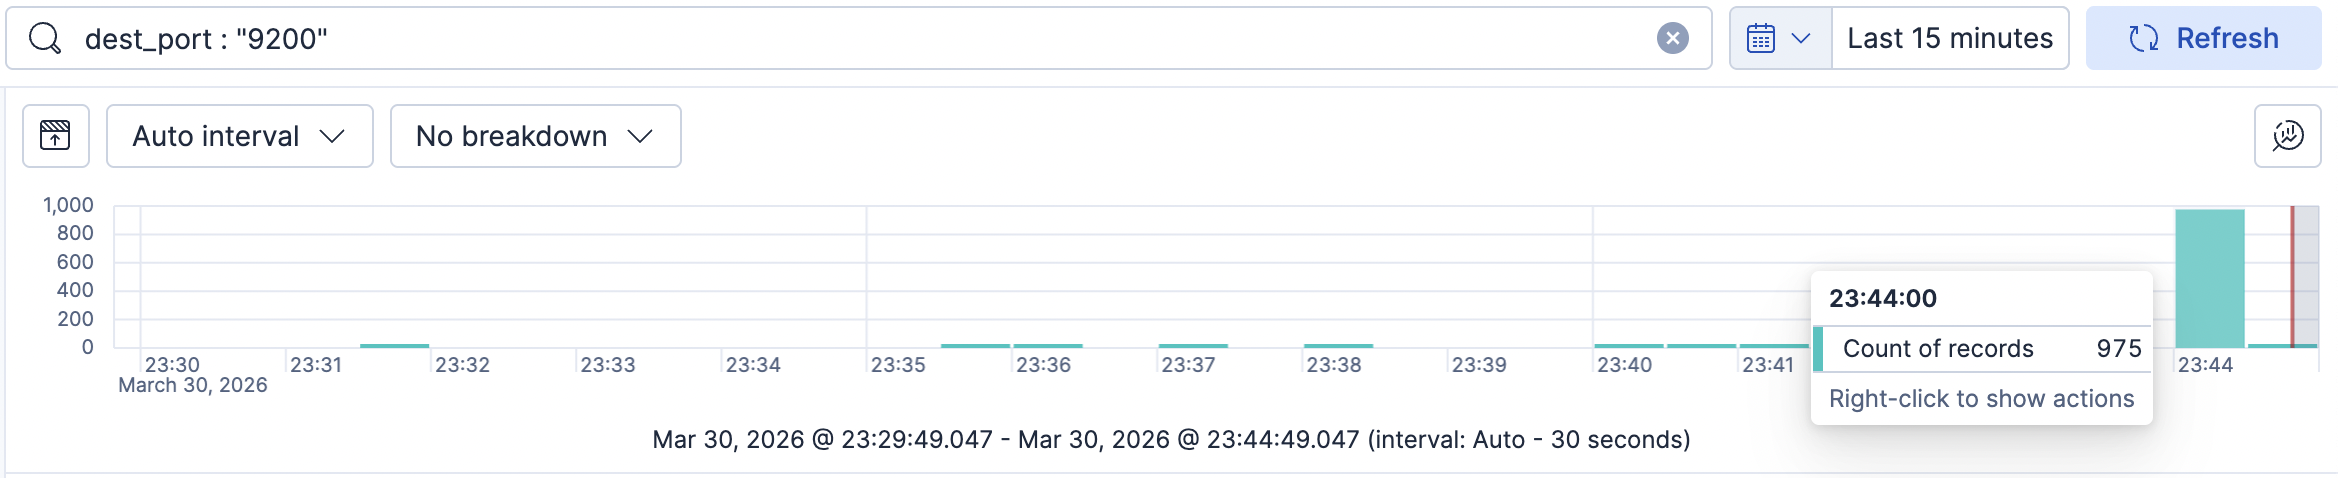

#### Simulation d'une exfiltration de données

Ce script sert à générer un scenario d’extraction de données depuis Elasticsearch en enchaînant des requêtes sur plusieurs index. Il donne un aperçu pratique du volume récupérable, de la quantité de données échangées.

In [82]:
target  = "https://localhost:9200"
auth    = ("elastic", "changeme")

indices = ["_all", ".ds-suricata*", "Suricata-logs"]
results = {"docs": 0, "bytes": 0, "err": 0}

for index in indices:
    try:
        r = requests.post(
            f"{target}/{index}/_search?scroll=1m",
            auth=auth, verify=False, timeout=5,
            json={"size": 100, "query": {"match_all": {}}}
        )
        if r.ok:
            data        = r.json()
            scroll_id   = data.get("_scroll_id", "")
            hits        = data.get("hits", {}).get("hits", [])
            results["docs"]  += len(hits)
            results["bytes"] += len(r.content)

            for page in range(10):
                if not scroll_id:
                    break
                r2 = requests.post(
                    f"{target}/_search/scroll",
                    auth=auth, verify=False, timeout=5,
                    json={"scroll": "1m", "scroll_id": scroll_id}
                )
                if r2.ok:
                    data2     = r2.json()
                    scroll_id = data2.get("_scroll_id", "")
                    hits2     = data2.get("hits", {}).get("hits", [])
                    results["docs"]  += len(hits2)
                    results["bytes"] += len(r2.content)
                    if not hits2:
                        break
                else:
                    results["err"] += 1
                time.sleep(0.05)

        else:
            results["err"] += 1

    except Exception:
        results["err"] += 1

    try:
        requests.get(f"{target}/{index}/_mapping", auth=auth, verify=False, timeout=3)
        requests.get(f"{target}/{index}/_stats",   auth=auth, verify=False, timeout=3)
    except Exception:
        pass

    time.sleep(0.2)

print(f"\n--- RECAP  {target}----------------")
print(f"  Indices ciblés   {len(indices)}")
print(f"  Docs extraits    {results['docs']}")
print(f"  Bytes transférés {results['bytes']:,}")
print(f"  Erreurs          {results['err']}")
print(f"------------------------------")


--- RECAP  https://localhost:9200----------------
  Indices ciblés   3
  Docs extraits    2200
  Bytes transférés 3,279,588
  Erreurs          1
------------------------------


## 4. Détection d'anomalies sans ML

## 4. Détection d'anomalie (sans Machine Learning)

L'objectif est de construire des règles qui détectent vos simulations de comportements précédents.

Un exemple de détection d'anomalies basiques basées sur des règles:
```python
def detect_anomalies_basic():
    """Détecte des anomalies sans ML"""
    anomalies = []
    
    # 1. IPs sources avec beaucoup d'alertes différentes (scan suspect)
    query = {
        "size": 0,
        "query": {"term": {"event_type": "alert"}},
        "aggs": {
            "suspicious_ips": {
                "terms": {"field": "src_ip", "size": 10},
                "aggs": {
                    "unique_signatures": {"cardinality": {"field": "alert.signature_id"}},
                    "unique_dest_ips": {"cardinality": {"field": "dest_ip"}},
                    "total_alerts": {"value_count": {"field": "event_type"}}
                }
            }
        }
    }
    
    result = es.search(index=index_name, body=query)
    
    print("Détection d'anomalies (règles basiques)\n")

    for bucket in result['aggregations']['suspicious_ips']['buckets']:
        ip = bucket['key']
        unique_sigs = bucket['unique_signatures']['value']
        unique_dests = bucket['unique_dest_ips']['value']
        total = bucket['total_alerts']['value']
        
        # Critères d'anomalie
        if unique_sigs > 3 or unique_dests > 5:
            anomalies.append({
                "ip": ip,
                "type": "Scan suspect",
                "signatures": unique_sigs,
                "destinations": unique_dests,
                "total": total
            })
            print(f"🚨 {ip}: {unique_sigs} signatures, {unique_dests} destinations ({total} alertes)")

    return anomalies

anomalies = detect_anomalies_basic()
if not anomalies:
    print("\nAucune anomalie détectée avec les règles basiques")
```

Nous avons mis en place des règles simples pour détecter des anomalies réseau à partir des données stockées dans Elasticsearch. L’idée est d’analyser l’activité récente afin de repérer des comportements suspects comme des scans de ports, des pics de requêtes HTTP ou des tentatives d’exfiltration. Nous nous appuyons sur des agrégations (nombre de flux, diversité des ports, activité dans le temps) pour identifier ces patterns, puis nous regroupons les résultats par adresse IP avec un niveau de risque, afin d’obtenir une première analyse claire et exploitable

In [87]:
def detect_anomalies_basic():
    anomalies = []
    WINDOW = "now-24h"

    print("--------------------------------------" )
    print("-----> Règle 1 — Scan de ports")
    print("--------------------------------------" )

    result = es.search(index=index_name, body={
        "size": 0,
        "query": {"range": {"@timestamp": {"gte": WINDOW}}},
        "aggs": {
            "per_src": {
                "terms": {"field": "src_ip", "size": 20},
                "aggs": {
                    "unique_ports": {"cardinality": {"field": "dest_port"}},
                    "unique_dests": {"cardinality": {"field": "dest_ip"}},
                    "total": {"value_count": {"field": "src_ip"}},
                    "per_minute": {
                        "date_histogram": {"field": "@timestamp", "fixed_interval": "1m"},
                        "aggs": {"ports_min": {"cardinality": {"field": "dest_port"}}}
                    }
                }
            }
        }
    })

    buckets = result.get("aggregations", {}).get("per_src", {}).get("buckets", [])
    found = False

    for b in buckets:
        ip           = b["key"]
        unique_ports = b["unique_ports"]["value"]
        unique_dests = b["unique_dests"]["value"]
        total        = b["total"]["value"]
        peak         = max((w["ports_min"]["value"] for w in b["per_minute"]["buckets"]), default=0)

        if unique_ports >= 4 and (unique_dests >= 3 or peak >= 3):
            found = True
            print(f"PORT_SCAN {ip}")
            print(f"   flows={total} | ports={unique_ports} | dests={unique_dests} | pic_ports/min={peak}")
            anomalies.append({"ip": ip, "type": "port_scan",
                               "flows": total, "ports": unique_ports, "peak": peak, "risk": 7})

    if not found:
        print("   Aucun scan détecté.")


    print("--------------------------------------" )
    print("-----> Règle 2 — HTTP Burst (port 9200)")
    print("--------------------------------------" )

    result2 = es.search(index=index_name, body={
        "size": 0,
        "query": {
            "bool": {"must": [
                {"term":  {"dest_port": 9200}},
                {"range": {"@timestamp": {"gte": WINDOW}}}
            ]}
        },
        "aggs": {
            "per_src": {
                "terms": {"field": "src_ip", "size": 10},
                "aggs": {
                    "total": {"value_count": {"field": "src_ip"}},
                    "per_minute": {
                        "date_histogram": {"field": "@timestamp", "fixed_interval": "1m"},
                        "aggs": {"count": {"value_count": {"field": "src_ip"}}}
                    }
                }
            }
        }
    })

    buckets2 = result2.get("aggregations", {}).get("per_src", {}).get("buckets", [])
    found = False

    for b in buckets2:
        ip    = b["key"]
        total = b["total"]["value"]
        peak  = max((w["count"]["value"] for w in b["per_minute"]["buckets"]), default=0)

        if peak > 300:
            found = True
            print(f"HTTP_BURST {ip}")
            print(f"   flows={total} | pic/min={peak}")
            anomalies.append({"ip": ip, "type": "http_burst",
                               "flows": total, "peak": peak, "risk": 9})

    if not found:
        print("   Aucun burst détecté.")

    print("--------------------------------------" )
    print("-----> Règle 3 — Exfiltration")
    print("--------------------------------------" )

    result3 = es.search(index=index_name, body={
        "size": 0,
        "query": {
            "bool": {"must": [
                {"term":  {"dest_port": 9200}},
                {"exists": {"field": "flow.bytes_toserver"}},
                {"range": {"@timestamp": {"gte": WINDOW}}}
            ]}
        },
        "aggs": {
            "per_src": {
                "terms": {"field": "src_ip", "size": 10},
                "aggs": {
                    "total_bytes": {"sum":        {"field": "flow.bytes_toserver"}},
                    "total_pkts":  {"sum":        {"field": "flow.pkts_toserver"}},
                    "nb_flows":    {"value_count": {"field": "src_ip"}},
                    "per_minute": {
                        "date_histogram": {"field": "@timestamp", "fixed_interval": "1m"},
                        "aggs": {"bytes_min": {"sum": {"field": "flow.bytes_toserver"}}}
                    }
                }
            }
        }
    })

    buckets3 = result3.get("aggregations", {}).get("per_src", {}).get("buckets", [])
    hits3    = result3.get("hits", {}).get("total", {}).get("value", 0)
    print(f"   Flows avec bytes_toserver : {hits3}")
    found = False

    for b in buckets3:
        ip            = b["key"]
        total_bytes   = b["total_bytes"]["value"] or 0
        total_pkts    = b["total_pkts"]["value"]  or 0
        nb_flows      = b["nb_flows"]["value"]
        mb            = round(total_bytes / 1024 / 1024, 2)
        max_bytes_min = max(
            (w["bytes_min"]["value"] or 0 for w in b["per_minute"]["buckets"]),
            default=0
        )

        if total_bytes > 1 * 1024 * 1024 and nb_flows > 50 and max_bytes_min > 200_000:
            found = True
            print(f"EXFILTRATION {ip}")
            print(f"   {mb} MB | {total_pkts} paquets | {nb_flows} flows | "
                  f"pic {round(max_bytes_min/1024)}KB/min")
            anomalies.append({"ip": ip, "type": "exfiltration",
                               "flows": nb_flows, "mb": mb,
                               "peak_kb_min": round(max_bytes_min / 1024), "risk": 10})

    if not found:
        print("   Pas de bytes_toserver — fallback sur src_ports distincts...")
        result3b = es.search(index=index_name, body={
            "size": 0,
            "query": {
                "bool": {"must": [
                    {"term":  {"dest_port": 9200}},
                    {"range": {"@timestamp": {"gte": WINDOW}}}
                ]}
            },
            "aggs": {
                "per_src": {
                    "terms": {"field": "src_ip", "size": 10},
                    "aggs": {
                        "nb_flows":     {"value_count": {"field": "src_ip"}},
                        "unique_sports": {"cardinality": {"field": "src_port"}}
                    }
                }
            }
        })
        for b in result3b.get("aggregations", {}).get("per_src", {}).get("buckets", []):
            ip            = b["key"]
            nb_flows      = b["nb_flows"]["value"]
            unique_sports = b["unique_sports"]["value"]
            if nb_flows > 100 and unique_sports > 15:
                found = True
                print(f"EXFILTRATION (fallback) {ip}")
                print(f"   {nb_flows} flows | {unique_sports} src_ports distincts vers :9200")
                anomalies.append({"ip": ip, "type": "exfiltration",
                                   "flows": nb_flows, "unique_sports": unique_sports, "risk": 10})
        if not found:
            print("   Aucune exfiltration détectée.")


    print("--------------------------------------" )
    print("-----> Résumé par IP")
    print("--------------------------------------" )

    summary = {}
    for a in anomalies:
        ip = a["ip"]
        if ip not in summary:
            summary[ip] = {"flows": 0, "alerts": [], "max_risk": 0}
        summary[ip]["flows"]    += a.get("flows", 0)
        summary[ip]["max_risk"]  = max(summary[ip]["max_risk"], a.get("risk", 0))
        summary[ip]["alerts"].append(a["type"])

    for ip, data in summary.items():
        print(f"  {ip}  risk={data['max_risk']}/10  "
              f"flows={data['flows']}  alerts={data['alerts']}")

    print()
    print("--------------------------------------" )
    print(f"-----> Total anomalies détectées : {len(anomalies)}")
    return anomalies

anomalies = detect_anomalies_basic()

--------------------------------------
-----> Règle 1 — Scan de ports
--------------------------------------
PORT_SCAN 192.168.65.1
   flows=54518 | ports=5 | dests=8 | pic_ports/min=4
PORT_SCAN 169.254.169.254
   flows=29 | ports=29 | dests=1 | pic_ports/min=5
PORT_SCAN 172.18.0.8
   flows=29 | ports=29 | dests=1 | pic_ports/min=5
PORT_SCAN 192.168.65.7
   flows=25 | ports=13 | dests=1 | pic_ports/min=11
PORT_SCAN 172.18.0.7
   flows=18 | ports=18 | dests=1 | pic_ports/min=3
PORT_SCAN 172.18.0.6
   flows=7 | ports=7 | dests=1 | pic_ports/min=7
PORT_SCAN 172.18.0.5
   flows=5 | ports=5 | dests=1 | pic_ports/min=3
--------------------------------------
-----> Règle 2 — HTTP Burst (port 9200)
--------------------------------------
HTTP_BURST 192.168.65.1
   flows=3496 | pic/min=1026
--------------------------------------
-----> Règle 3 — Exfiltration
--------------------------------------
   Flows avec bytes_toserver : 3496
EXFILTRATION 192.168.65.1
   8.6 MB | 39325.0 paquets | 3496 flo

## 5. Détection d'anomalies avec ML

L'objectif est d'à partir de données labelisées comme étant anomarles ou non, construire un jeu de donnée et entrainer un algorithme de machine learning (classifier binaire) sur ces données. Le modèle devra ensuite etre appelé pour prédire les futurs comportements anormaux.

Indice: le modèle Isolation Forest pourrait etre utile

Dans cette partie, nous mettons en place une approche de détection d’anomalies basée sur le machine learning à partir des données Elasticsearch. Nous construisons un dataset de features agrégées par adresse IP, que nous normalisons avant d’appliquer un modèle non supervisé de type Isolation Forest. Ce modèle permet d’identifier automatiquement les comportements atypiques sans règle prédéfinie, en attribuant un score d’anomalie à chaque IP et en mettant en évidence les sources les plus suspectes.

In [98]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

query_ml = {
    "size": 5000,
    "query": {
        "bool": {
            "must": [{"exists": {"field": "src_ip"}}],
            "filter": [{"range": {"@timestamp": {"gte": "now-24h"}}}]
        }
    },
    "_source": ["src_ip", "dest_ip", "dest_port", "proto", "event_type", "@timestamp"]
}

hits = es.search(index=index_name, body=query_ml)["hits"]["hits"]
print(f"   {len(hits)} événements récupérés")

records = []
for h in hits:
    src = h["_source"]
    records.append({
        "src_ip":     src.get("src_ip",    "0.0.0.0"),
        "dest_ip":    src.get("dest_ip",   "0.0.0.0"),
        "dest_port":  int(src.get("dest_port", 0)),
        "proto":      src.get("proto",     "unknown"),
        "event_type": src.get("event_type","unknown"),
        "timestamp":  src.get("@timestamp","")
    })

df = pd.DataFrame(records)

df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)
df = df.dropna(subset=["timestamp"]).sort_values("timestamp")

print(f"   DataFrame : {df.shape[0]} lignes")

agg = df.groupby("src_ip").agg(
    total_events  = ("event_type", "count"),
    unique_dests  = ("dest_ip",    "nunique"),
    unique_ports  = ("dest_port",  "nunique"),
    nb_flows      = ("event_type", lambda x: (x == "flow").sum()),
    nb_alerts     = ("event_type", lambda x: (x == "alert").sum()),
    unique_protos = ("proto",      "nunique"),
).reset_index()

agg["alert_ratio"] = (agg["nb_alerts"] / agg["total_events"].replace(0, 1)).round(4)

print(f"\n -----> {agg.shape[0]} IPs sources uniques")

FEATURES = [
    "total_events",
    "unique_dests",
    "unique_ports",
    "nb_flows",
    "nb_alerts",
    "alert_ratio",
    "unique_protos"
]

X = agg[FEATURES].fillna(0).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = IsolationForest(
    n_estimators=200,
    contamination=0.1,
    random_state=42
)

model.fit(X_scaled)

agg["anomaly_score"] = model.decision_function(X_scaled)  # plus négatif = suspect
agg["prediction"]    = model.predict(X_scaled)            # -1 = anomalie

anomalies_ml = agg[agg["prediction"] == -1].sort_values("anomaly_score")

print(f"\n -----> Anomalies détectées : {len(anomalies_ml)} / {len(agg)} IPs")

for _, row in anomalies_ml.iterrows():
    print(f" {row['src_ip']:20s} | "
          f"score={row['anomaly_score']:.4f} | "
          f"events={row['total_events']:5.0f} | "
          f"dests={row['unique_dests']:4.0f} | "
          f"ports={row['unique_ports']:4.0f} | "
          f"alerts={row['nb_alerts']:4.0f}")

print("\n -----> Top 10 IPs les plus suspectes :")

top_anomalies = agg.sort_values("anomaly_score").head(10)

for _, row in top_anomalies.iterrows():
    flag = " " if row["prediction"] == -1 else " "
    print(f"{flag} {row['src_ip']:20s} | "
          f"score={row['anomaly_score']:.4f} | "
          f"events={row['total_events']:5.0f} | "
          f"dests={row['unique_dests']:4.0f} | "
          f"ports={row['unique_ports']:4.0f} | "
          f"alerts={row['nb_alerts']:4.0f}")

print("\n -----> Distribution des scores :")
print(agg["anomaly_score"].describe())

print("\n -----> Répartition :")
counts = agg["prediction"].value_counts()
print(f"   Normal   : {counts.get(1, 0)}")
print(f"   Anomalie : {counts.get(-1, 0)}")



   5000 événements récupérés
   DataFrame : 5000 lignes

 -----> 4 IPs sources uniques

 -----> Anomalies détectées : 1 / 4 IPs
 192.168.65.1         | score=-0.0618 | events= 4982 | dests=   3 | ports=   3 | alerts=   0

 -----> Top 10 IPs les plus suspectes :
  192.168.65.1         | score=-0.0618 | events= 4982 | dests=   3 | ports=   3 | alerts=   0
  192.168.65.7         | score=0.1442 | events=    8 | dests=   1 | ports=   8 | alerts=   0
  172.18.0.8           | score=0.1571 | events=    2 | dests=   1 | ports=   2 | alerts=   0
  192.168.65.3         | score=0.2186 | events=    8 | dests=   1 | ports=   1 | alerts=   0

 -----> Distribution des scores :
count    4.000000
mean     0.114510
std      0.121927
min     -0.061785
25%      0.092677
50%      0.150637
75%      0.172470
max      0.218551
Name: anomaly_score, dtype: float64

 -----> Répartition :
   Normal   : 3
   Anomalie : 1


## Bonus
- améliorer la stack (ex: ajout de Wazuh)
- dashboard Kibana pour voir en live les simulations de comportements anormaux et les détection d'anomalie (timeline des alertes, etc.)
- analyse statistique avancée
- simulations de comportement anormaux avancée
- utilisation du module de détection d'anomalie d'Elasticsearch (https://www.elastic.co/docs/explore-analyze/machine-learning/anomaly-detection)
- collaboration en groupe sur le projet Git (Pull requests, commits, etc.)
- utilisation de docker / docker compose / devcontainer
- etc.